# Continuous Bidirectional Local-PIV Marker Tracking

This notebook uses **local particle image velocimetry (PIV)** to track equine anatomical markers between manually annotated keyframes.

### Processing approach

1. Treat each pair of adjacent keyframes as an independent segment.
2. Track frame by frame from the left keyframe to the right, and simultaneously from the right keyframe to the left.
3. Fuse bidirectional estimates for interior frames: when the two coordinates are no more than `18 px` apart, weight them linearly by the frame's temporal position within the segment.
4. Keep a one-direction estimate when it is the only valid result; mark conflicting bidirectional coordinates as `missing` without speculative interpolation.
5. Always prioritize manual keyframe annotations at segment endpoints.

> The coordinate system follows the image: the origin is at the top left, `x` increases to the right, and `y` increases downward.


In [2]:
%matplotlib inline
# Standard library: path handling, JSON parsing, and mathematical operations.
from pathlib import Path
import json
import math

# Third-party libraries: OpenCV for video processing, NumPy for computation, Pandas for tabular data, and Matplotlib for plotting.
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# OpenPIV performs local correlation matching; if unavailable, show the installation command for the project version.
try:
    import openpiv
    from openpiv import pyprocess
except ImportError as exc:
    raise ImportError(
        'OpenPIV is not installed. Run this in the equine environment: python -m pip install OpenPIV==0.25.4'
    ) from exc
from IPython.display import Image, Video, display

# Report the runtime version for reproducibility and version-difference diagnostics.
OPENPIV_VERSION = getattr(openpiv, '__version__', 'unknown')
print('OpenPIV version:', OPENPIV_VERSION)


OpenPIV version: 0.25.4


In [ ]:
def resolve_project_root():
    """Infer the project root from the notebook's current working directory.

    Support launching Jupyter from either the project root or the scripts/ directory.
    The project root must contain both the scripts/ and workspaces/ directories.
    """
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'scripts').is_dir() and (candidate / 'workspaces').is_dir():
            return candidate
    raise RuntimeError(f'Could not locate the project root from the current directory: {cwd}')


PROJECT_ROOT = resolve_project_root()

# ===== This is usually the only setting users need to change =====
# Path to the keyframe annotation JSON; it may be absolute or relative to the project root.
ANNOTATION_JSON_PATH = (
    PROJECT_ROOT / 'workspaces' / 'IMG_3104_processed' /
    'annotations' / 'keyframe_marker_points.json'
)


In [4]:
# Default marker names. Tracking uses marker_names from the annotation JSON.
MARKER_NAMES = [
    'wither', 'shoulder', 'elbow', 'knee', 'front_fetlock', 'front_coronet',
    'tuber_coxae', 'hip', 'stifle', 'hock', 'hind_fetlock', 'hind_coronet',
]

# These connections are used only in the overlay video and do not affect coordinate quality checks.
SKELETON_EDGES = [
    ('wither', 'shoulder'), ('shoulder', 'elbow'), ('elbow', 'knee'),
    ('knee', 'front_fetlock'), ('front_fetlock', 'front_coronet'),
    ('tuber_coxae', 'hip'), ('hip', 'stifle'), ('stifle', 'hock'),
    ('hock', 'hind_fetlock'), ('hind_fetlock', 'hind_coronet'),
]

# Maximum allowed distance in pixels between forward and backward coordinates; larger differences are bidirectional conflicts.
DIRECTION_CONFLICT_THRESHOLD = 18.0
# Maximum overlay-video frame rate; higher-frame-rate source videos are subsampled at a fixed stride.
MAX_OVERLAY_FPS = 30.0


# PIV interrogation-window size: side length of the previous-frame region centered on the marker and used for correlation matching.
PIV_INTERROGATION_SIZE = 24
# PIV search-area size: current-frame region in which to locate the template; it must be larger than the interrogation window.
PIV_SEARCH_AREA_SIZE = 56
# Only one displacement vector is computed per marker, so window overlap is unnecessary.
PIV_OVERLAP = 0
# Minimum correlation-peak signal-to-noise ratio; tracking results below this value are rejected.
PIV_S2N_THRESHOLD = 1.20
# Minimum grayscale standard deviation; overly flat texture cannot produce a reliable correlation peak.
PIV_MIN_TEXTURE_STD = 4.0
# Maximum per-frame displacement is determined by the size difference between the search area and interrogation window, with a 1 px boundary margin.
PIV_MAX_DISPLACEMENT_PX = (
    PIV_SEARCH_AREA_SIZE - PIV_INTERROGATION_SIZE
) / 2 - 1

# Status and method labels used in output files for downstream statistics and provenance.
TRACKED_STATUS = 'piv_tracked'
TRACKING_METHOD = 'Continuous bidirectional local-PIV with temporal fusion'
PLOT_TITLE = 'Continuous bidirectional local-PIV Marker trajectories'


## 1. Load and Validate Annotations

This section reads the keyframe JSON, validates required fields, keyframe ranges, and the video path, and converts all coordinates to floating-point values.

The JSON must contain at least `video`, `keyframes`, `marker_names`, and `points`. `points` is keyed by frame-number strings, and each marker value is either `[x, y]` or `null`.


In [5]:
# Convert the configured path to a normalized absolute path and report path errors before computation.
annotation_path = Path(ANNOTATION_JSON_PATH).expanduser()
if not annotation_path.is_absolute():
    annotation_path = PROJECT_ROOT / annotation_path
annotation_path = annotation_path.resolve()
if not annotation_path.is_file():
    raise FileNotFoundError(f'Annotation JSON does not exist: {annotation_path}')

# Read the annotation data and first verify that all required top-level fields are present.
payload = json.loads(annotation_path.read_text(encoding='utf-8'))
required_keys = {'video', 'keyframes', 'marker_names', 'points'}
missing_keys = required_keys - payload.keys()
if missing_keys:
    raise ValueError(f'Annotation JSON is missing fields: {sorted(missing_keys)}')
if len(payload['keyframes']) < 2:
    raise ValueError('At least two keyframes are required for tracking.')

# The annotation file is expected under <task_dir>/annotations/, while the video path is stored relative to task_dir.
task_dir = annotation_path.parent.parent
video_path = (task_dir / payload['video']['stored_path']).resolve()
if not video_path.is_file():
    raise FileNotFoundError(f'Task video does not exist: {video_path}')

# Convert frame numbers to integers and sort them so adjacent segments are processed chronologically.
keyframes = sorted(map(int, payload['keyframes']))
if len(set(keyframes)) != len(keyframes):
    raise ValueError('Keyframe indices must be unique.')
marker_names = list(payload['marker_names'])
if not marker_names:
    raise ValueError('marker_names must not be empty.')

# Every keyframe must have a points entry; an individual point may be None when manually confirmed as invisible.
raw_points = payload['points']
for frame_index in keyframes:
    if str(frame_index) not in raw_points:
        raise ValueError(f'Missing points for keyframe {frame_index}.')
# anchor_points has the structure {frame_index: {marker_name: (x, y) | None}}.
# Convert explicitly to float to prevent integer truncation in subsequent NumPy/OpenCV operations.
anchor_points = {
    frame_index: {
        name: (
            None if raw_points[str(frame_index)].get(name) is None
            else tuple(map(float, raw_points[str(frame_index)][name]))
        )
        for name in marker_names
    }
    for frame_index in keyframes
}

# Prefer metadata from the video container; fall back to the JSON values only when OpenCV returns no valid value.
cap = cv2.VideoCapture(str(video_path))
if not cap.isOpened():
    raise RuntimeError(f'OpenCV could not open {video_path}')
fps = float(cap.get(cv2.CAP_PROP_FPS) or payload['video']['fps'])
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or payload['video']['frame_count'])
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or payload['video']['width'])
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or payload['video']['height'])
cap.release()

# The complete tracking range must lie within the video's [0, frame_count - 1] interval.
if keyframes[0] < 0 or keyframes[-1] >= frame_count:
    raise ValueError('Keyframes fall outside the video range.')

# Write all CSV files, trajectory plots, and overlay videos to this directory.
output_dir = task_dir / 'piv_tracking'
output_dir.mkdir(parents=True, exist_ok=True)

{'video': str(video_path), 'keyframes': keyframes, 'output_dir': str(output_dir)}


FileNotFoundError: Annotation JSON does not exist: /Users/addicted/Downloads/Xiaoyu/workspaces/Horses_videos_1_processed/annotations/keyframe_marker_points.json

## 2. Continuous Forward/Backward PIV and Temporally Weighted Fusion

For each keyframe interval `[start_frame, end_frame]`, the program propagates frame by frame from both endpoints. Let an interior frame be $t$ and the segment span be $T=end-start$; when the bidirectional estimates agree, use:

$$w_f = \frac{end-t}{T}, \qquad w_b = \frac{t-start}{T}$$

$$p(t) = w_f p_f(t) + w_b p_b(t)$$

Thus, forward propagation receives more weight near the left keyframe, while backward propagation receives more weight near the right keyframe; the two weights always sum to 1.

In [5]:
def load_segment_frames(start_frame, end_frame):
    """Read all BGR video frames in the closed interval [start_frame, end_frame].

    Caching the current segment in memory lets forward and backward tracking reuse the same frames,
    avoiding duplicate video decoding. Return a {frame_index: BGR_frame} dictionary.
    """
    cap = cv2.VideoCapture(str(video_path))
    # Seek the decoder to the first frame of the segment.
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(start_frame))
    frames = {}
    for frame_index in range(start_frame, end_frame + 1):
        ok, frame = cap.read()
        if not ok:
            cap.release()
            raise RuntimeError(f'Could not read frame {frame_index}')
        frames[frame_index] = frame
    cap.release()
    return frames


def to_gray(frame):
    """Convert OpenCV BGR input to a single grayscale channel because PIV uses intensity only."""
    return cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)


def extract_piv_roi(gray, point, size=PIV_SEARCH_AREA_SIZE):
    """Extract a square search region centered on ``point``.

    Return ``None`` if the point is absent, the search box crosses the image boundary, or the slice size is incomplete.
    Do not pad boundaries with zeros because artificial padding changes the correlation peak and may create false displacement.
    """
    if point is None:
        return None
    # Pixel slicing requires an integer center, so round the floating-point coordinates first.
    half = size // 2
    center_x, center_y = int(round(point[0])), int(round(point[1]))
    x1, y1 = center_x - half, center_y - half
    x2, y2 = x1 + size, y1 + size
    # NumPy image shape is ordered as (height, width), while coordinates are ordered as (x, y).
    if x1 < 0 or y1 < 0 or x2 > gray.shape[1] or y2 > gray.shape[0]:
        return None
    roi = gray[y1:y2, x1:x2]
    return roi if roi.shape == (size, size) else None


def piv_displacement(previous_gray, current_gray, point):
    """Estimate a marker's local displacement from the previous frame to the current frame.

    Use the central interrogation window in the previous-frame ROI as the template and perform an extended search
    within the current-frame search area at the same center. On success, return ``(dx, dy, s2n)``: the first two values are
    pixels per frame, and the third is the signal-to-noise ratio of the first and second correlation peaks; return None if any quality check fails.
    """
    # Center both frame ROIs on the current estimate; the larger search box accommodates motion in the next frame.
    previous_roi = extract_piv_roi(previous_gray, point)
    current_roi = extract_piv_roi(current_gray, point)
    if previous_roi is None or current_roi is None:
        return None

    # Use only the small central window of the previous-frame search region as the texture template.
    half = PIV_SEARCH_AREA_SIZE // 2
    inquiry_half = PIV_INTERROGATION_SIZE // 2
    inquiry = previous_roi[
        half - inquiry_half:half + inquiry_half,
        half - inquiry_half:half + inquiry_half,
    ]
    # Flat texture usually produces a non-unique correlation peak; reject it before calling OpenPIV.
    if (
        float(np.std(inquiry)) < PIV_MIN_TEXTURE_STD
        or float(np.std(current_roi)) < PIV_MIN_TEXTURE_STD
    ):
        return None

    # extended_search_area_piv returns u, v, and s2n arrays with shape (1, 1).
    # dt=1 means the output u and v values are pixel displacements per frame.
    try:
        u, v, s2n = pyprocess.extended_search_area_piv(
            previous_roi.astype(np.int32),
            current_roi.astype(np.int32),
            window_size=PIV_INTERROGATION_SIZE,
            overlap=PIV_OVERLAP,
            dt=1.0,
            search_area_size=PIV_SEARCH_AREA_SIZE,
            # Linear correlation prevents wraparound matches at search-area boundaries.
            correlation_method='linear',
            # Apply Gaussian subpixel fitting to the correlation peak to obtain floating-point displacement.
            subpixel_method='gaussian',
            sig2noise_method='peak2peak',
            width=3,
            normalized_correlation=True,
            use_vectorized=False,
        )
    except (FloatingPointError, ValueError, IndexError):
        return None

    dx, dy, signal_to_noise = float(u[0, 0]), float(v[0, 0]), float(s2n[0, 0])
    # NaN/Inf values cannot be used as coordinates; displacement beyond the search geometry limit is also invalid.
    if not np.all(np.isfinite([dx, dy, signal_to_noise])):
        return None
    if abs(dx) > PIV_MAX_DISPLACEMENT_PX or abs(dy) > PIV_MAX_DISPLACEMENT_PX:
        return None
    return dx, dy, signal_to_noise


def piv_one_direction(previous_gray, current_gray, point):
    """Perform one frame-to-frame update and quality check for one marker in one direction.

    Return ``(new_coordinate, is_valid, dx, dy, s2n)``. Even if the coordinate is out of bounds or S2N is insufficient,
    dx/dy/s2n are still returned whenever PIV produced output, enabling diagnostics in the directional CSV.
    """
    if point is None:
        return None, False, np.nan, np.nan, np.nan
    result = piv_displacement(previous_gray, current_gray, point)
    if result is None:
        return None, False, np.nan, np.nan, np.nan
    dx, dy, s2n = result
    # Add the PIV displacement to the previous-frame coordinate to form a continuously propagated trajectory.
    tracked = (float(point[0] + dx), float(point[1] + dy))
    in_bounds = 0 <= tracked[0] < width and 0 <= tracked[1] < height
    ok = in_bounds and s2n >= PIV_S2N_THRESHOLD
    return tracked, ok, dx, dy, s2n


def make_direction_row(
    segment_id,
    direction,
    frame_index,
    name,
    point,
    status,
    dx=np.nan,
    dy=np.nan,
    s2n=np.nan,
):
    """Format one directional tracking result as a standard row for the directional CSV.

    ``piv_dx_px``/``piv_dy_px`` store one-step displacement along the propagation direction; velocity columns are converted
    to pixels per second in the forward video-time direction, so backward tracking must divide by -1.
    """
    time_step = 1 if direction == 'forward' else -1
    return {
        'segment_id': segment_id,
        'direction': direction,
        'frame_index': frame_index,
        'timestamp_s': frame_index / fps,
        'marker_name': name,
        'x': np.nan if point is None else point[0],
        'y': np.nan if point is None else point[1],
        'tracking_status': status,
        'piv_dx_px': dx,
        'piv_dy_px': dy,
        # Multiplying dx/dy by FPS gives px/s; time_step standardizes velocity signs across forward and backward tracking.
        'piv_u_px_s': np.nan if np.isnan(dx) else dx * fps / time_step,
        'piv_v_px_s': np.nan if np.isnan(dy) else dy * fps / time_step,
        'piv_s2n': s2n,
        'quality_flag': 'ok' if point is not None else 'missing',
    }




In [6]:
def track_direction(frames, segment_id, start_frame, end_frame, direction):
    """Track an entire segment continuously in the specified direction from a manual keyframe.

    Forward calls satisfy start < end, while backward calls satisfy start > end. Each marker independently maintains
    its current coordinate and active state; after its first failure, the marker is disabled and no longer propagated from an unreliable position.
    """
    step = 1 if direction == 'forward' else -1
    # Because range excludes its stop value, use end_frame + step to include the right/left endpoint.
    sequence = list(range(start_frame, end_frame + step, step))
    start_points = anchor_points[start_frame]
    # When the starting manual point is None, keep it inactive from the beginning.
    states = {
        name: {
            'point': start_points.get(name),
            'active': start_points.get(name) is not None,
        }
        for name in marker_names
    }
    # Write the manual anchor directly for the first frame without running PIV.
    rows = [
        make_direction_row(
            segment_id,
            direction,
            start_frame,
            name,
            start_points.get(name),
            'keyframe_anchor' if start_points.get(name) is not None else 'missing',
        )
        for name in marker_names
    ]

    previous_gray = to_gray(frames[start_frame])
    for frame_index in sequence[1:]:
        current_gray = to_gray(frames[frame_index])
        for name in marker_names:
            state = states[name]
            # Append only missing rows for failed trajectories so the output retains a complete frame-by-marker grid.
            if not state['active']:
                rows.append(make_direction_row(
                    segment_id, direction, frame_index, name, None, 'missing',
                ))
                continue

            tracked, ok, dx, dy, s2n = piv_one_direction(
                previous_gray,
                current_gray,
                state['point'],
            )
            if ok:
                # Update the center for the next step only when both boundary and S2N checks pass.
                state['point'] = tracked
                rows.append(make_direction_row(
                    segment_id, direction, frame_index, name,
                    tracked, 'piv_tracked', dx, dy, s2n,
                ))
            else:
                # Continuous propagation cannot restart after skipping a failed frame because that would remove the basis for trajectory continuity.
                state['point'] = None
                state['active'] = False
                rows.append(make_direction_row(
                    segment_id, direction, frame_index, name,
                    None, 'missing', dx, dy, s2n,
                ))
        # After all markers are processed, the current frame becomes the previous frame for the next iteration.
        previous_gray = current_gray
    return pd.DataFrame(rows)


In [7]:
def fuse_segment(forward, backward, segment_id, start_frame, end_frame):
    """Fuse forward and backward tracking results for one segment.

    Fusion priority: manual endpoint anchor > consistent bidirectionally weighted result > valid one-direction result > missing.
    The returned table retains pre-fusion coordinates, directional error, and weights for quality auditing.
    """
    # Use (frame index, marker) as a composite key so each lookup is O(1).
    forward_lookup = forward.set_index(['frame_index', 'marker_name']).to_dict('index')
    backward_lookup = backward.set_index(['frame_index', 'marker_name']).to_dict('index')
    rows = []
    # span is used for temporal weights; validated unique keyframes guarantee span > 0.
    span = end_frame - start_frame

    for frame_index in range(start_frame, end_frame + 1):
        for name in marker_names:
            forward_row = forward_lookup[(frame_index, name)]
            backward_row = backward_lookup[(frame_index, name)]
            # Missing coordinates are represented by NaN in CSV/DataFrame data and converted to None for branching logic.
            forward_point = (
                None if pd.isna(forward_row['x'])
                else (float(forward_row['x']), float(forward_row['y']))
            )
            backward_point = (
                None if pd.isna(backward_row['x'])
                else (float(backward_row['x']), float(backward_row['y']))
            )
            # Bidirectional error is the Euclidean distance in pixels between the two predicted coordinates.
            direction_error = (
                np.nan if forward_point is None or backward_point is None
                else float(np.hypot(
                    forward_point[0] - backward_point[0],
                    forward_point[1] - backward_point[1],
                ))
            )

            # Initialize as missing; only results accepted by the branches below are written to final coordinates.
            point = None
            status = 'missing'
            flag = 'missing'
            forward_weight = np.nan
            backward_weight = np.nan

            # Always use manual annotations at final segment endpoints, never automatically propagated coordinates from the opposite endpoint.
            if frame_index in (start_frame, end_frame):
                point = anchor_points[frame_index].get(name)
                if point is not None:
                    status = 'keyframe_anchor'
                    flag = 'ok'
                    forward_weight = 1.0 if frame_index == start_frame else 0.0
                    backward_weight = 0.0 if frame_index == start_frame else 1.0
            elif forward_point is not None and backward_point is not None:
                # Both directions are valid: check consistency before applying temporal weighting.
                if direction_error <= DIRECTION_CONFLICT_THRESHOLD:
                    # Forward weight is near 1 at the left endpoint and decreases over time; backward weight behaves oppositely.
                    forward_weight = (end_frame - frame_index) / span
                    backward_weight = (frame_index - start_frame) / span
                    point = (
                        forward_weight * forward_point[0] + backward_weight * backward_point[0],
                        forward_weight * forward_point[1] + backward_weight * backward_point[1],
                    )
                    status = 'bidirectional_fused'
                    flag = 'ok'
                else:
                    # When the discrepancy is too large, do not arbitrarily choose a side; retain the conflict flag for review.
                    flag = 'direction_conflict'
            elif forward_point is not None:
                # When only forward or backward tracking succeeds, use the sole valid coordinate directly.
                point = forward_point
                status = 'forward_only'
                flag = 'ok'
                forward_weight = 1.0
                backward_weight = 0.0
            elif backward_point is not None:
                point = backward_point
                status = 'backward_only'
                flag = 'ok'
                forward_weight = 0.0
                backward_weight = 1.0

            # Save both raw directional values and the final value so fusion does not discard diagnostic information.
            rows.append({
                'segment_id': segment_id,
                'frame_index': frame_index,
                'timestamp_s': frame_index / fps,
                'marker_name': name,
                'forward_x': np.nan if forward_point is None else forward_point[0],
                'forward_y': np.nan if forward_point is None else forward_point[1],
                'backward_x': np.nan if backward_point is None else backward_point[0],
                'backward_y': np.nan if backward_point is None else backward_point[1],
                'forward_status': forward_row['tracking_status'],
                'backward_status': backward_row['tracking_status'],
                'direction_error': direction_error,
                'forward_weight': forward_weight,
                'backward_weight': backward_weight,
                'x': np.nan if point is None else point[0],
                'y': np.nan if point is None else point[1],
                'tracking_status': status,
                'quality_flag': flag,
            })
    return pd.DataFrame(rows)


In [8]:
# Three accumulators store directional details, segment-level fused details, and segment quality summaries.
directional_frames = []
fused_segments = []
quality_rows = []

# zip pairs the keyframe sequence into adjacent segments: (k0, k1), (k1, k2), ...
print(f'{len(keyframes)-1} segments in total.')
for segment_id, (start_frame, end_frame) in enumerate(zip(keyframes[:-1], keyframes[1:])):
    print(f'segment {segment_id + 1}: frame {start_frame} to {end_frame}')
    frames = load_segment_frames(start_frame, end_frame)
    # Forward tracking uses the left anchor; backward tracking swaps endpoints to use the right anchor.
    forward = track_direction(frames, segment_id, start_frame, end_frame, 'forward')
    backward = track_direction(frames, segment_id, end_frame, start_frame, 'backward')
    fused = fuse_segment(forward, backward, segment_id, start_frame, end_frame)
    directional_frames.extend([forward, backward])
    fused_segments.append(fused)
    # Count rows by status for each segment to quickly locate intervals with poor tracking quality.
    quality_rows.append({
        'segment_id': segment_id,
        'start_frame': start_frame,
        'end_frame': end_frame,
        'row_count': len(fused),
        'valid_rows': int(fused.x.notna().sum()),
        'anchor_rows': int(fused.tracking_status.eq('keyframe_anchor').sum()),
        'forward_tracked_rows': int(forward.tracking_status.eq(TRACKED_STATUS).sum()),
        'backward_tracked_rows': int(backward.tracking_status.eq(TRACKED_STATUS).sum()),
        'bidirectional_fused_rows': int(fused.tracking_status.eq('bidirectional_fused').sum()),
        'forward_only_rows': int(fused.tracking_status.eq('forward_only').sum()),
        'backward_only_rows': int(fused.tracking_status.eq('backward_only').sum()),
        'direction_conflict_rows': int(fused.quality_flag.eq('direction_conflict').sum()),
        'missing_rows': int(fused.tracking_status.eq('missing').sum()),
    })
    # Release the frame-dictionary reference after each segment to reduce peak memory for long videos.
    del frames


5 segments in total.
segment 1: frame 350 to 510
segment 2: frame 510 to 670
segment 3: frame 670 to 830
segment 4: frame 830 to 990
segment 5: frame 990 to 1150


In [9]:
quality_df = pd.DataFrame(quality_rows)
# display(quality_df)

In [10]:
# Concatenate local tables from all segments vertically into complete datasets.
directional_df = pd.concat(directional_frames, ignore_index=True)
validated_df = pd.concat(fused_segments, ignore_index=True)

# Adjacent segments overlap only at shared manual keyframes. Visible manual anchors have highest priority;
# retain missing when manual annotation confirms invisibility, and do not average across segments.
final_rows = []
for _, group in validated_df.groupby(['frame_index', 'marker_name'], sort=True):
    # A shared keyframe belongs to both adjacent segments; always prefer a visible manual anchor when present.
    anchors = group[group.tracking_status.eq('keyframe_anchor') & group.x.notna()]
    chosen = anchors.iloc[0] if not anchors.empty else group.iloc[0]
    final_rows.append(chosen)
final_df = (
    pd.DataFrame(final_rows)
    .sort_values(['frame_index', 'marker_name'])
    .reset_index(drop=True)
)


## 3. Export and Visualization

This section produces two CSV files and two visualizations. Intermediate `validated_df` remains in memory only to generate `final_df`, while segment quality summary `quality_df` is displayed directly in the notebook:

- `marker_tracks_directional.csv`: raw details from separate forward and backward tracking;
- `marker_tracks_final.csv`: final trajectories after removing duplicate shared-keyframe rows;
- `marker_tracking_overlay.mp4`: markers and skeleton connections overlaid on the source video;
- `marker_trajectories.png`: two-dimensional trajectories of all valid markers.


In [11]:
# Define output paths centrally to avoid repeatedly assembling filenames below.
directional_csv = output_dir / 'marker_tracks_directional.csv'
final_csv = output_dir / 'marker_tracks_final.csv'

# index=False prevents temporary DataFrame row indices from becoming extra CSV columns.
directional_df.to_csv(directional_csv, index=False)
final_df.to_csv(final_csv, index=False)

print('Saved:', directional_csv)
print('Saved:', final_csv)


Saved: /Users/xiaoyu/Desktop/equine/workspaces/Horses_videos_1_processed/piv_tracking/marker_tracks_directional.csv
Saved: /Users/xiaoyu/Desktop/equine/workspaces/Horses_videos_1_processed/piv_tracking/marker_tracks_final.csv


In [12]:
def marker_color(name):
    """Generate a stable color from the marker's position in marker_names and return OpenCV BGR order."""
    index = marker_names.index(name)
    # Matplotlib's colormap returns RGB in [0, 1]; scale to [0, 255] and reverse to BGR.
    rgb = np.asarray(plt.cm.tab20(index % 20)[:3]) * 255
    return tuple(int(value) for value in rgb[::-1])


def draw_overlay(frame, frame_rows):
    """Draw valid markers, names, and skeleton connections on a copy of one frame."""
    canvas = frame.copy()
    # Add only rows with final coordinates to the drawing dictionary; missing/conflicting points are not shown.
    rows = {row['marker_name']: row for row in frame_rows if not pd.isna(row['x'])}
    # Draw a skeleton edge only when both endpoints are visible, avoiding connections to missing positions.
    for first, second in SKELETON_EDGES:
        if first in rows and second in rows:
            point_a, point_b = rows[first], rows[second]
            cv2.line(
                canvas,
                (round(point_a['x']), round(point_a['y'])),
                (round(point_b['x']), round(point_b['y'])),
                (255, 255, 255),
                1,
            )
    for name, row in rows.items():
        x, y = round(row['x']), round(row['y'])
        color = marker_color(name)
        status = row['tracking_status']
        # Shape encoding: manual anchor = large circle with center, one-direction result = square, bidirectional fusion = regular circle.
        if status == 'keyframe_anchor':
            cv2.circle(canvas, (x, y), 8, color, 2)
            cv2.circle(canvas, (x, y), 2, color, -1)
        elif status in ('forward_only', 'backward_only'):
            cv2.rectangle(canvas, (x - 5, y - 5), (x + 5, y + 5), color, 2)
        else:
            cv2.circle(canvas, (x, y), 6, color, 2)
        cv2.putText(
            canvas, name, (x + 7, y - 7), cv2.FONT_HERSHEY_SIMPLEX,
            0.38, color, 1, cv2.LINE_AA,
        )
    return canvas


overlay_path = output_dir / 'marker_tracking_overlay.mp4'
# Compute the sampling stride: for example, a 60 FPS source with a 30 FPS limit writes one of every two frames.
overlay_stride = max(1, int(math.ceil(fps / MAX_OVERLAY_FPS)))
overlay_fps = fps / overlay_stride
# mp4v offers broad compatibility; output dimensions must match the source video.
writer = cv2.VideoWriter(
    str(overlay_path), cv2.VideoWriter_fourcc(*'mp4v'),
    overlay_fps, (width, height),
)
if not writer.isOpened():
    raise RuntimeError(f'Could not create {overlay_path}')

# Index tracks by frame number first to avoid scanning all of final_df for every output frame.
tracks_by_frame = {
    frame_index: group.to_dict('records')
    for frame_index, group in final_df.groupby('frame_index')
}
# Decode only frames between the first and last keyframes.
cap = cv2.VideoCapture(str(video_path))
cap.set(cv2.CAP_PROP_POS_FRAMES, keyframes[0])
for frame_index in range(keyframes[0], keyframes[-1] + 1):
    ok, frame = cap.read()
    if not ok:
        break
    if (frame_index - keyframes[0]) % overlay_stride == 0:
        writer.write(draw_overlay(frame, tracks_by_frame.get(frame_index, [])))
cap.release()
writer.release()

print('Saved:', overlay_path)

Saved: /Users/xiaoyu/Desktop/equine/workspaces/Horses_videos_1_processed/piv_tracking/marker_tracking_overlay.mp4


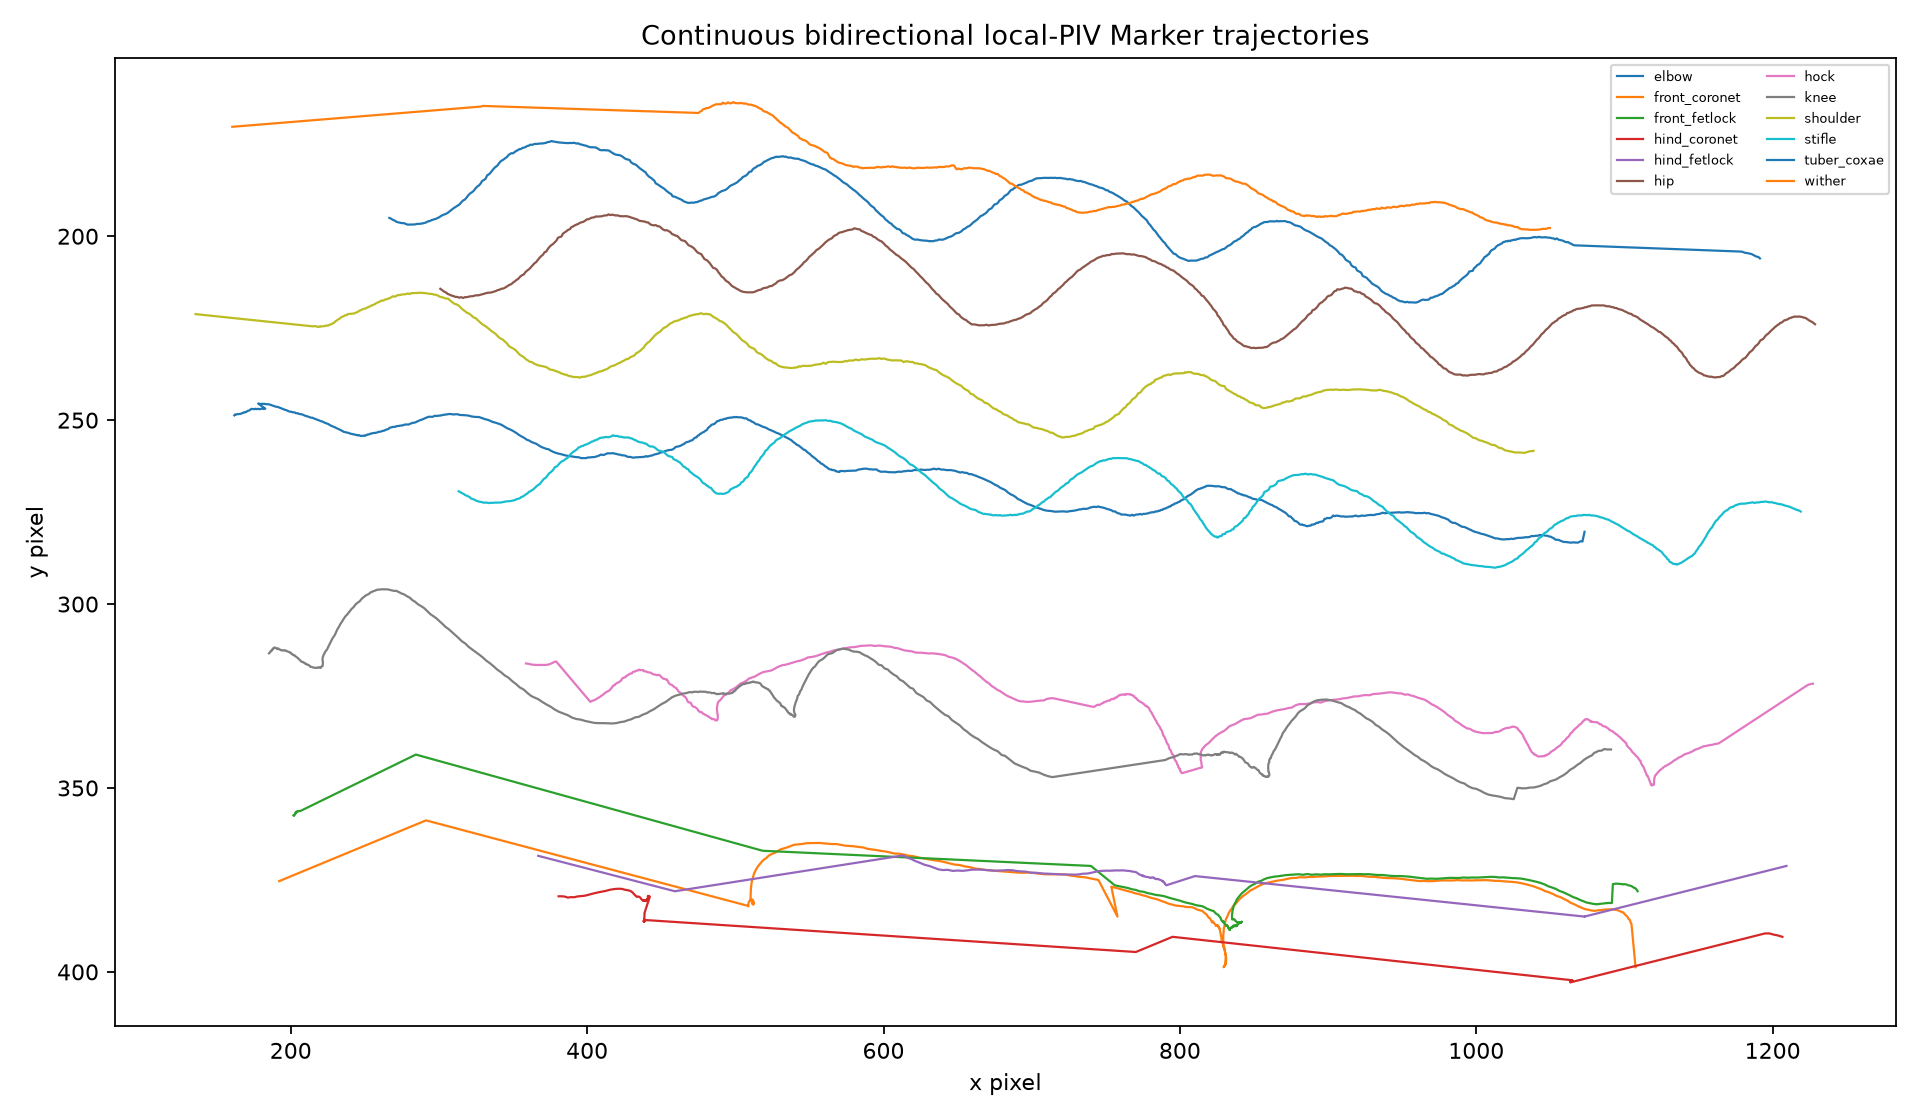

Saved: /Users/xiaoyu/Desktop/equine/workspaces/Horses_videos_1_processed/piv_tracking/marker_tracking_overlay.mp4


In [13]:
# Plot two-dimensional pixel-coordinate trajectories, one curve per marker.
trajectory_path = output_dir / 'marker_trajectories.png'
plt.figure(figsize=(12, 7))
for name, group in final_df.dropna(subset=['x', 'y']).groupby('marker_name', sort=False):
    plt.plot(group.x, group.y, linewidth=1, label=name)
# Matplotlib's y-axis points upward by default; invert it to match image coordinates, where y points downward.
plt.gca().invert_yaxis()
plt.xlabel('x pixel')
plt.ylabel('y pixel')
plt.title(PLOT_TITLE)
plt.legend(ncol=2, fontsize=6)
plt.tight_layout()
plt.savefig(trajectory_path, dpi=160)
plt.close()

display(Image(filename=str(trajectory_path)))
# print('Overlay stride:', overlay_stride, 'output FPS:', overlay_fps)
print('Saved:', overlay_path)

In [14]:
# Summarize inputs, algorithm parameters, quality counts, and artifact paths for experiment records and reproducibility.
summary = {
    'annotation_json': str(annotation_path),
    'video': str(video_path),
    'keyframes': keyframes,
    'processed_range': (keyframes[0], keyframes[-1]),
    'marker_count': len(marker_names),
    'tracking_method': TRACKING_METHOD,
    'direction_conflict_threshold': DIRECTION_CONFLICT_THRESHOLD,
    'valid_rows': int(final_df.x.notna().sum()),
    'total_rows': len(final_df),
    'status_counts': final_df.tracking_status.value_counts(dropna=False).to_dict(),
    'quality_counts': final_df.quality_flag.value_counts(dropna=False).to_dict(),
    'final_csv': str(final_csv),
    'overlay_video': str(overlay_path),
    'trajectory_plot': str(trajectory_path),
}
summary


{'annotation_json': '/Users/xiaoyu/Desktop/equine/workspaces/Horses_videos_1_processed/annotations/keyframe_marker_points.json',
 'video': '/Users/xiaoyu/Desktop/equine/workspaces/Horses_videos_1_processed/input/Horses videos - 1.MOV',
 'keyframes': [350, 510, 670, 830, 990, 1150],
 'processed_range': (350, 1150),
 'marker_count': 12,
 'tracking_method': 'Continuous bidirectional local-PIV with temporal fusion',
 'direction_conflict_threshold': 18.0,
 'valid_rows': 7011,
 'total_rows': 9612,
 'status_counts': {'bidirectional_fused': 4051,
  'missing': 2601,
  'backward_only': 1858,
  'forward_only': 1030,
  'keyframe_anchor': 72},
 'quality_counts': {'ok': 7011, 'missing': 2601},
 'final_csv': '/Users/xiaoyu/Desktop/equine/workspaces/Horses_videos_1_processed/piv_tracking/marker_tracks_final.csv',
 'overlay_video': '/Users/xiaoyu/Desktop/equine/workspaces/Horses_videos_1_processed/piv_tracking/marker_tracking_overlay.mp4',
 'trajectory_plot': '/Users/xiaoyu/Desktop/equine/workspaces/Ho